# 1. Análise Exploratória de Dados (EDA)

## Desafio Técnico - Cientista de Dados Pleno

Este notebook realiza a análise exploratória dos dados de consumo energético residencial,
dados climáticos e cadastro de clientes.

### Objetivos:
- Compreender a estrutura e qualidade dos dados
- Identificar padrões temporais e sazonais no consumo
- Analisar correlações entre variáveis climáticas e consumo
- Detectar inconsistências e valores ausentes
- Gerar insights para a modelagem preditiva

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 1.1 Carregamento dos Dados

In [2]:
consumo = pd.read_csv('../data/consumo.csv', parse_dates=['date'])
clima = pd.read_csv('../data/clima.csv', parse_dates=['date'])
clientes = pd.read_csv('../data/clientes.csv')

print(f'consumo.csv:  {consumo.shape[0]:,} linhas x {consumo.shape[1]} colunas')
print(f'clima.csv:    {clima.shape[0]:,} linhas x {clima.shape[1]} colunas')
print(f'clientes.csv: {clientes.shape[0]:,} linhas x {clientes.shape[1]} colunas')

consumo.csv:  18,000 linhas x 3 colunas
clima.csv:    900 linhas x 4 colunas
clientes.csv: 100 linhas x 2 colunas


## 1.2 Visão Geral dos Dados

In [3]:
print('=' * 60)
print('CONSUMO - Primeiras linhas')
print('=' * 60)
display(consumo.head(10))
print(f'\nPeríodo: {consumo.date.min().date()} a {consumo.date.max().date()}')
print(f'Clientes únicos: {consumo.client_id.nunique()}')
print(f'Dias únicos: {consumo.date.nunique()}')

CONSUMO - Primeiras linhas


,client_id,date,consumption_kwh
0,C0000,2023-01-01,18.64
1,C0000,2023-01-02,16.63
2,C0000,2023-01-03,18.11
3,C0000,2023-01-04,18.25
4,C0000,2023-01-05,19.81
5,C0000,2023-01-06,15.87
6,C0000,2023-01-07,20.30
7,C0000,2023-01-08,19.35
8,C0000,2023-01-09,18.30
9,C0000,2023-01-10,13.34



Período: 2023-01-01 a 2023-06-29
Clientes únicos: 100
Dias únicos: 180


In [4]:
print('=' * 60)
print('CLIMA - Primeiras linhas')
print('=' * 60)
display(clima.head(10))
print(f'\nRegiões: {sorted(clima.region.unique())}')
print(f'Período: {clima.date.min().date()} a {clima.date.max().date()}')

CLIMA - Primeiras linhas


,region,date,temperature,humidity
0,Centro,2023-01-01,25.652941,57.188235
1,Centro,2023-01-02,23.794118,52.517647
2,Centro,2023-01-03,22.900000,61.358824
3,Centro,2023-01-04,24.158824,64.223529
4,Centro,2023-01-05,24.870588,59.058824
5,Centro,2023-01-06,26.194118,59.629412
6,Centro,2023-01-07,23.905882,61.752941
7,Centro,2023-01-08,25.900000,60.117647
8,Centro,2023-01-09,25.688235,57.964706
9,Centro,2023-01-10,23.947059,54.088235



Regiões: ['Centro', 'Leste', 'Norte', 'Oeste', 'Sul']
Período: 2023-01-01 a 2023-06-29


In [5]:
print('=' * 60)
print('CLIENTES - Primeiras linhas')
print('=' * 60)
display(clientes.head(10))
print(f'\nDistribuição por região:')
print(clientes.region.value_counts().to_string())

CLIENTES - Primeiras linhas


,client_id,region
0,C0000,Norte
1,C0001,Norte
2,C0002,Sul
3,C0003,Norte
4,C0004,Oeste
5,C0005,Norte
6,C0006,Centro
7,C0007,Centro
8,C0008,Centro
9,C0009,Centro



Distribuição por região:
region
Norte           31
Leste           18
Centro          16
Sul             15
Oeste           15
Desconhecida     5


## 1.3 Análise de Dados Ausentes e Inconsistentes

In [6]:
print('=== Valores ausentes por dataset ===')
print('\n--- Consumo ---')
print(consumo.isnull().sum())
print(f'\n--- Clima ---')
print(clima.isnull().sum())
print(f'\nPercentual de temperaturas ausentes: {clima.temperature.isnull().mean()*100:.1f}%')
print(f'\n--- Clientes ---')
print(clientes.isnull().sum())

=== Valores ausentes por dataset ===

--- Consumo ---
client_id          0
date               0
consumption_kwh    0
dtype: int64

--- Clima ---
region          0
date            0
temperature    45
humidity        0
dtype: int64

Percentual de temperaturas ausentes: 5.0%

--- Clientes ---
client_id    0
region       0
dtype: int64


In [7]:
# Visualizar padrão dos dados faltantes de temperatura
temp_missing = clima[clima.temperature.isnull()]
print(f'Registros com temperatura ausente: {len(temp_missing)}')
print(f'\nDistribuição por região:')
print(temp_missing.region.value_counts().to_string())
print(f'\nDistribuição por mês:')
print(temp_missing.date.dt.month.value_counts().sort_index().to_string())

Registros com temperatura ausente: 45



Distribuição por região:
region
Leste     13
Norte     11
Centro     8
Oeste      7
Sul        6

Distribuição por mês:


date
1     6
2     6
3    11
4     6
5     7
6     9


In [8]:
# Identificar regiões inconsistentes nos clientes
regioes_validas = sorted(clima.region.unique())
regioes_clientes = sorted(clientes.region.unique())

print(f'Regiões válidas (clima): {regioes_validas}')
print(f'Regiões em clientes:     {regioes_clientes}')

inconsistentes = clientes[~clientes.region.isin(regioes_validas)]
print(f'\nClientes com região inválida ({len(inconsistentes)}):')
display(inconsistentes)

Regiões válidas (clima): ['Centro', 'Leste', 'Norte', 'Oeste', 'Sul']
Regiões em clientes:     ['Centro', 'Desconhecida', 'Leste', 'Norte', 'Oeste', 'Sul']

Clientes com região inválida (5):


,client_id,region
15,C0015,Desconhecida
50,C0050,Desconhecida
58,C0058,Desconhecida
77,C0077,Desconhecida
92,C0092,Desconhecida


## 1.4 Estatísticas Descritivas

In [9]:
print('=== Estatísticas do Consumo (kWh) ===')
display(consumo.consumption_kwh.describe().to_frame().T)

print('\n=== Estatísticas Climáticas ===')
display(clima[['temperature', 'humidity']].describe())

=== Estatísticas do Consumo (kWh) ===


,count,mean,std,min,25%,50%,75%,max
consumption_kwh,18000.0,14.811876,3.728855,2.64,12.07,14.89,17.63,27.92



=== Estatísticas Climáticas ===


,temperature,humidity
count,855.000000,900.000000
mean,25.097223,60.013529
std,1.174737,2.421545
min,21.313333,52.517647
25%,24.326563,58.456111
50%,25.035294,60.005556
75%,25.884375,61.565196
max,28.746667,69.111765


## 1.5 Distribuição do Consumo Energético

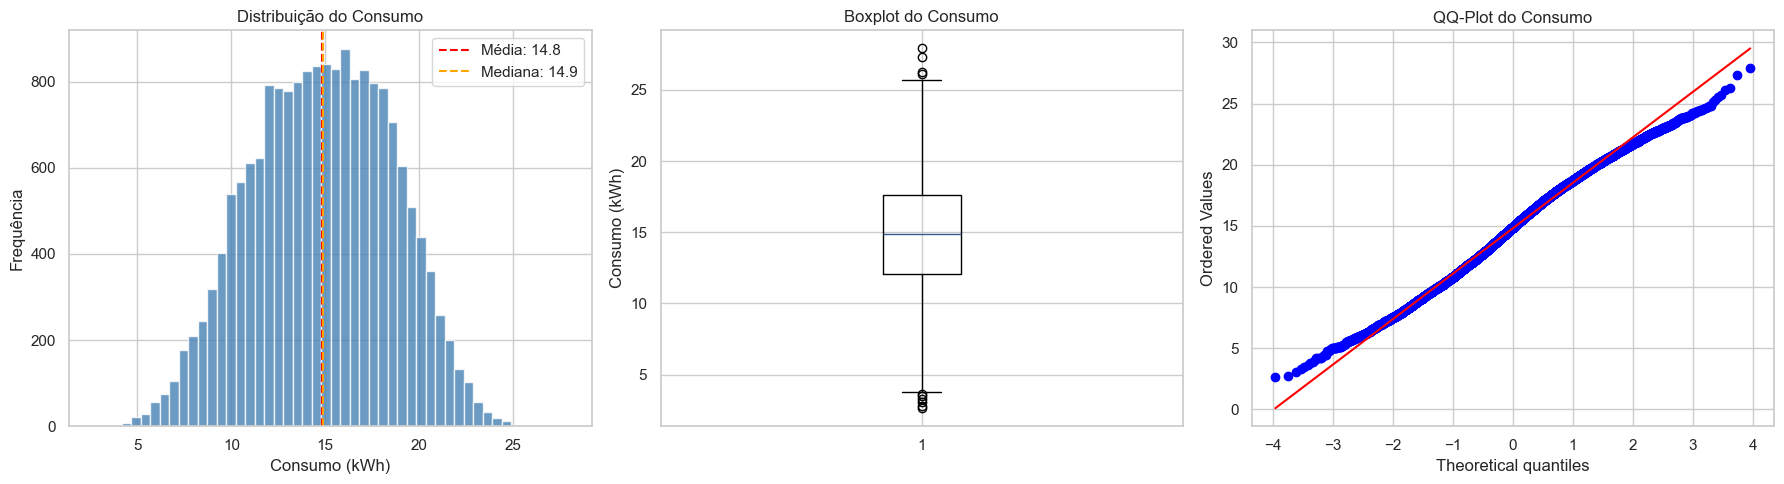

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
axes[0].hist(consumo.consumption_kwh, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(consumo.consumption_kwh.mean(), color='red', linestyle='--', label=f'Média: {consumo.consumption_kwh.mean():.1f}')
axes[0].axvline(consumo.consumption_kwh.median(), color='orange', linestyle='--', label=f'Mediana: {consumo.consumption_kwh.median():.1f}')
axes[0].set_xlabel('Consumo (kWh)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição do Consumo')
axes[0].legend()

# Boxplot
axes[1].boxplot(consumo.consumption_kwh, vert=True)
axes[1].set_ylabel('Consumo (kWh)')
axes[1].set_title('Boxplot do Consumo')

# QQ Plot
from scipy import stats
stats.probplot(consumo.consumption_kwh, dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot do Consumo')

plt.tight_layout()
plt.savefig('../notebooks/fig_distribuicao_consumo.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.6 Análise Temporal do Consumo

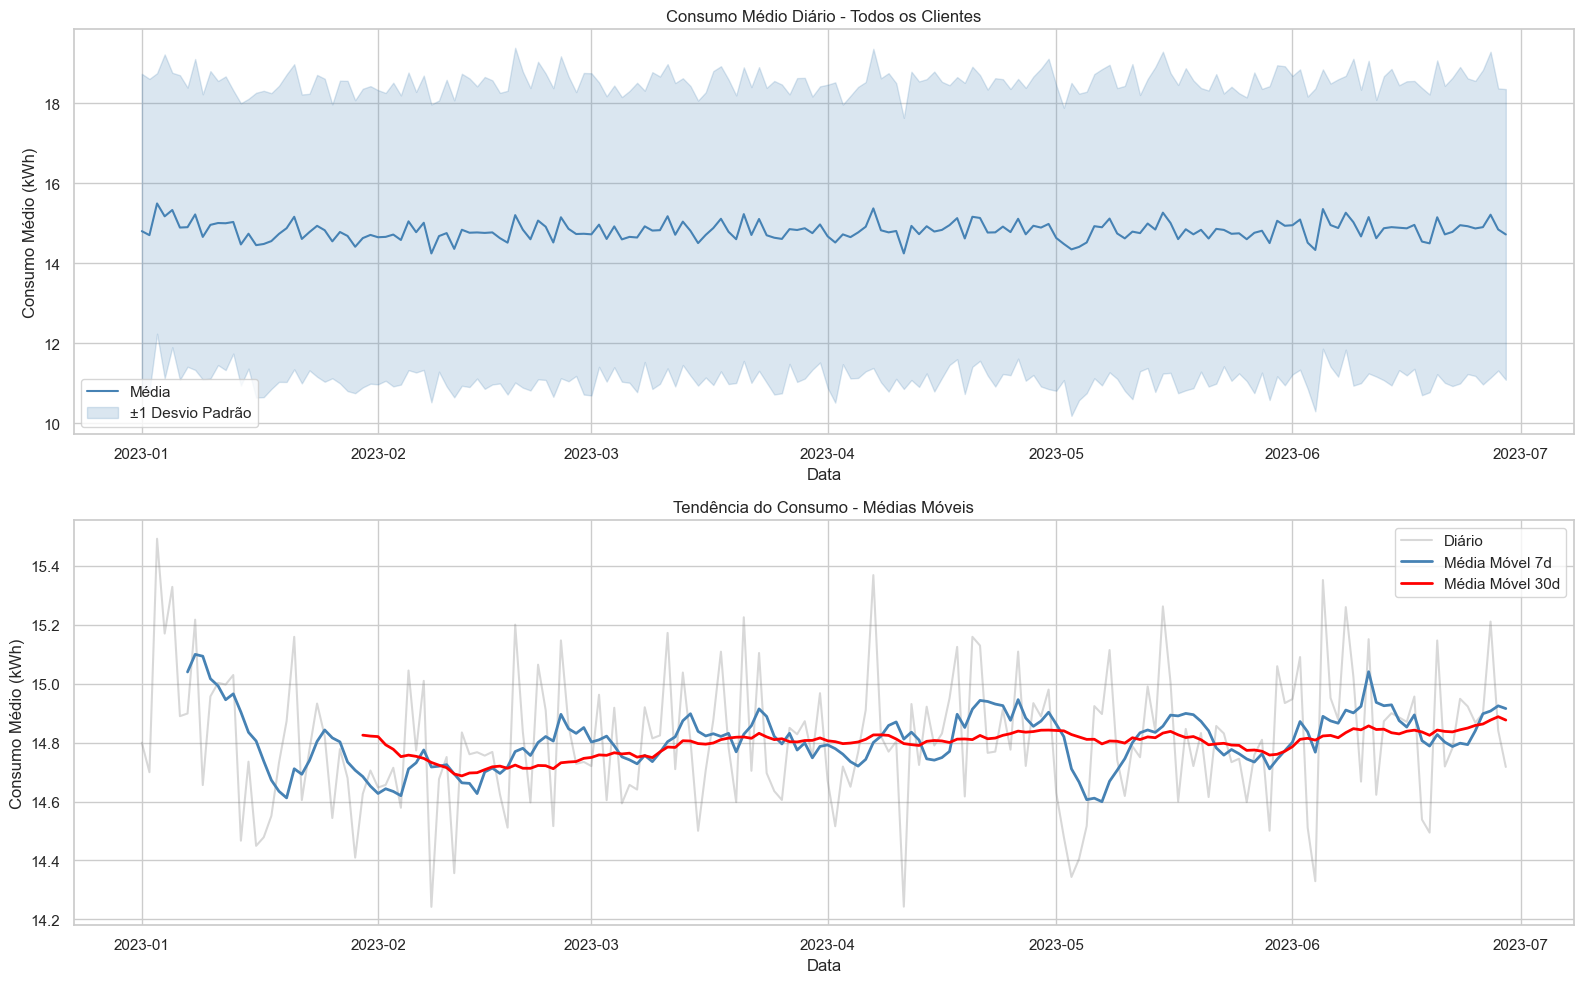

In [11]:
# Consumo médio diário (todos os clientes)
consumo_diario = consumo.groupby('date')['consumption_kwh'].agg(['mean', 'std', 'min', 'max']).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Série temporal com intervalo de confiança
axes[0].plot(consumo_diario['date'], consumo_diario['mean'], color='steelblue', linewidth=1.5, label='Média')
axes[0].fill_between(consumo_diario['date'],
                     consumo_diario['mean'] - consumo_diario['std'],
                     consumo_diario['mean'] + consumo_diario['std'],
                     alpha=0.2, color='steelblue', label='±1 Desvio Padrão')
axes[0].set_xlabel('Data')
axes[0].set_ylabel('Consumo Médio (kWh)')
axes[0].set_title('Consumo Médio Diário - Todos os Clientes')
axes[0].legend()

# Média móvel 7 dias
consumo_diario['ma7'] = consumo_diario['mean'].rolling(7).mean()
consumo_diario['ma30'] = consumo_diario['mean'].rolling(30).mean()
axes[1].plot(consumo_diario['date'], consumo_diario['mean'], alpha=0.3, color='gray', label='Diário')
axes[1].plot(consumo_diario['date'], consumo_diario['ma7'], color='steelblue', linewidth=2, label='Média Móvel 7d')
axes[1].plot(consumo_diario['date'], consumo_diario['ma30'], color='red', linewidth=2, label='Média Móvel 30d')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Consumo Médio (kWh)')
axes[1].set_title('Tendência do Consumo - Médias Móveis')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/fig_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

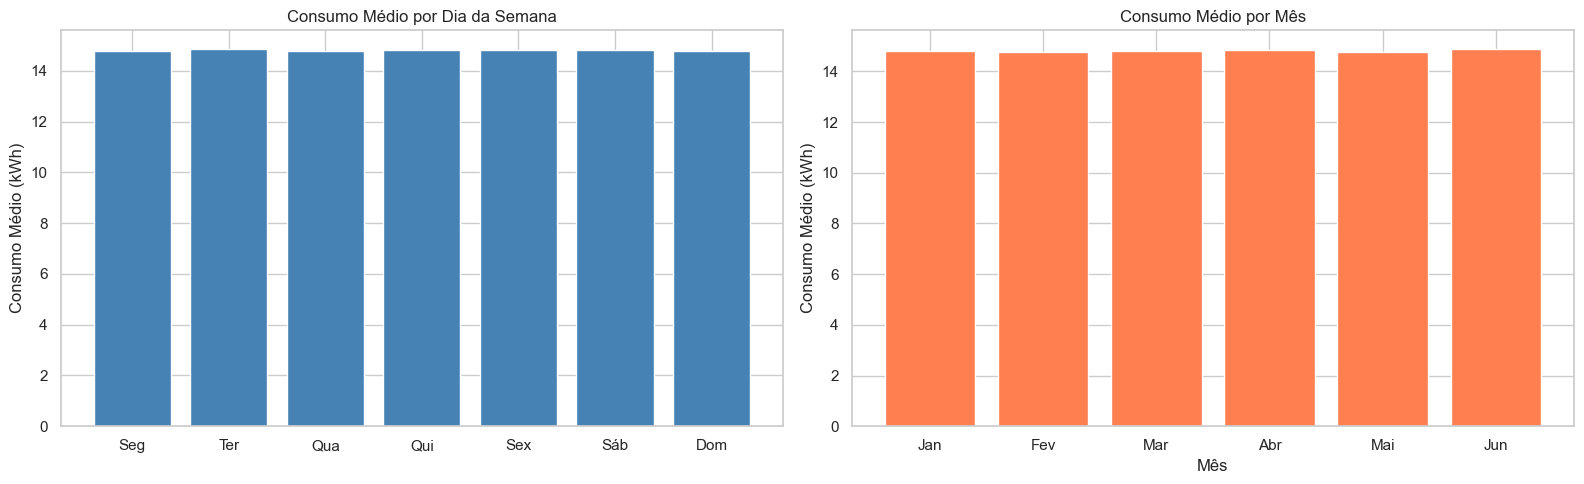

In [12]:
# Padrões por dia da semana e mês
consumo['day_of_week'] = consumo.date.dt.dayofweek
consumo['month'] = consumo.date.dt.month
consumo['day_name'] = consumo.date.dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Por dia da semana
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
consumo_dow = consumo.groupby('day_name')['consumption_kwh'].mean().reindex(dow_order)
axes[0].bar(range(7), consumo_dow.values, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])
axes[0].set_ylabel('Consumo Médio (kWh)')
axes[0].set_title('Consumo Médio por Dia da Semana')

# Por mês
consumo_mes = consumo.groupby('month')['consumption_kwh'].mean()
axes[1].bar(consumo_mes.index, consumo_mes.values, color='coral', edgecolor='white')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Consumo Médio (kWh)')
axes[1].set_title('Consumo Médio por Mês')
axes[1].set_xticks(consumo_mes.index)
axes[1].set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun'])

plt.tight_layout()
plt.savefig('../notebooks/fig_padrao_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.7 Análise por Região

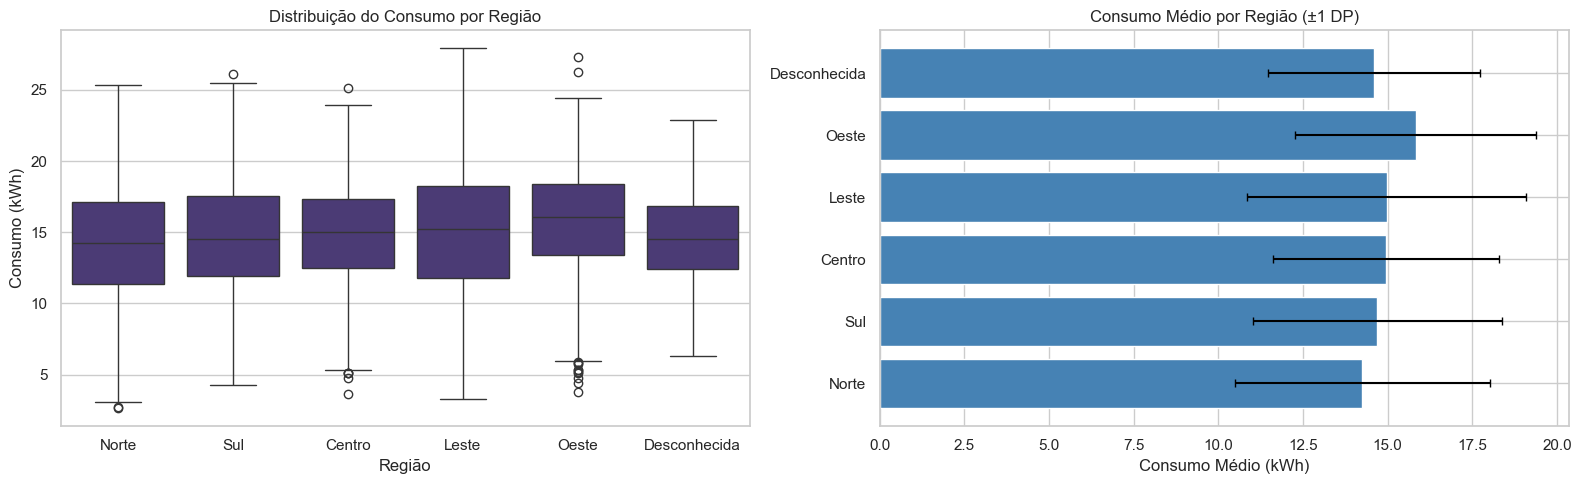


Estatísticas por região:


,mean,std,count
region,,,
Norte,14.25,3.77,5580
Sul,14.69,3.68,2700
Centro,14.95,3.34,2880
Leste,14.97,4.11,3240
Oeste,15.83,3.55,2700
Desconhecida,14.61,3.13,900


In [13]:
# Merge consumo com clientes para obter região
consumo_regiao = consumo.merge(clientes, on='client_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot por região
regioes_order = ['Norte', 'Sul', 'Centro', 'Leste', 'Oeste', 'Desconhecida']
sns.boxplot(data=consumo_regiao, x='region', y='consumption_kwh', order=regioes_order, ax=axes[0])
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Consumo (kWh)')
axes[0].set_title('Distribuição do Consumo por Região')

# Média e desvio por região
stats_regiao = consumo_regiao.groupby('region')['consumption_kwh'].agg(['mean', 'std', 'count'])
stats_regiao = stats_regiao.reindex(regioes_order)
axes[1].barh(stats_regiao.index, stats_regiao['mean'], xerr=stats_regiao['std'],
            color='steelblue', edgecolor='white', capsize=3)
axes[1].set_xlabel('Consumo Médio (kWh)')
axes[1].set_title('Consumo Médio por Região (±1 DP)')

plt.tight_layout()
plt.savefig('../notebooks/fig_consumo_regiao.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEstatísticas por região:')
display(stats_regiao.round(2))

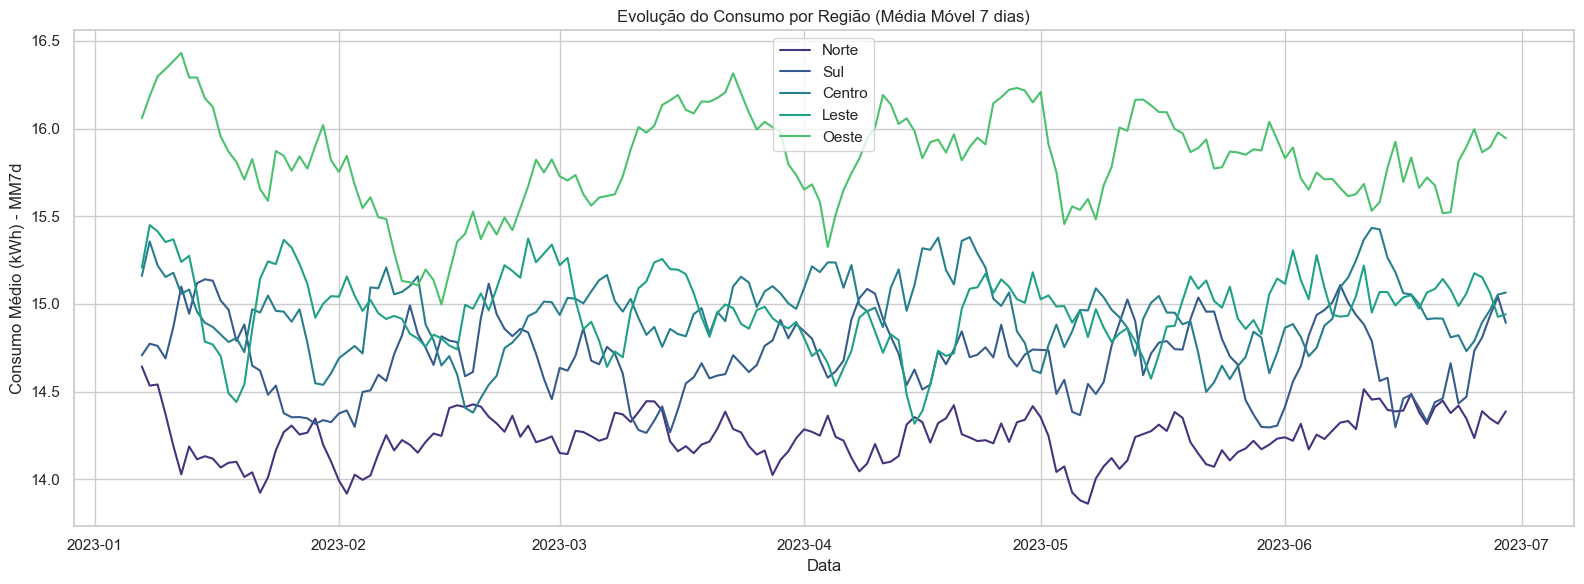

In [14]:
# Evolução temporal do consumo por região
consumo_regiao_tempo = consumo_regiao.groupby(['date', 'region'])['consumption_kwh'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
for regiao in ['Norte', 'Sul', 'Centro', 'Leste', 'Oeste']:
    dados_r = consumo_regiao_tempo[consumo_regiao_tempo.region == regiao]
    ma = dados_r.set_index('date')['consumption_kwh'].rolling(7).mean()
    ax.plot(ma.index, ma.values, label=regiao, linewidth=1.5)

ax.set_xlabel('Data')
ax.set_ylabel('Consumo Médio (kWh) - MM7d')
ax.set_title('Evolução do Consumo por Região (Média Móvel 7 dias)')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/fig_evolucao_regiao.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.8 Análise Climática

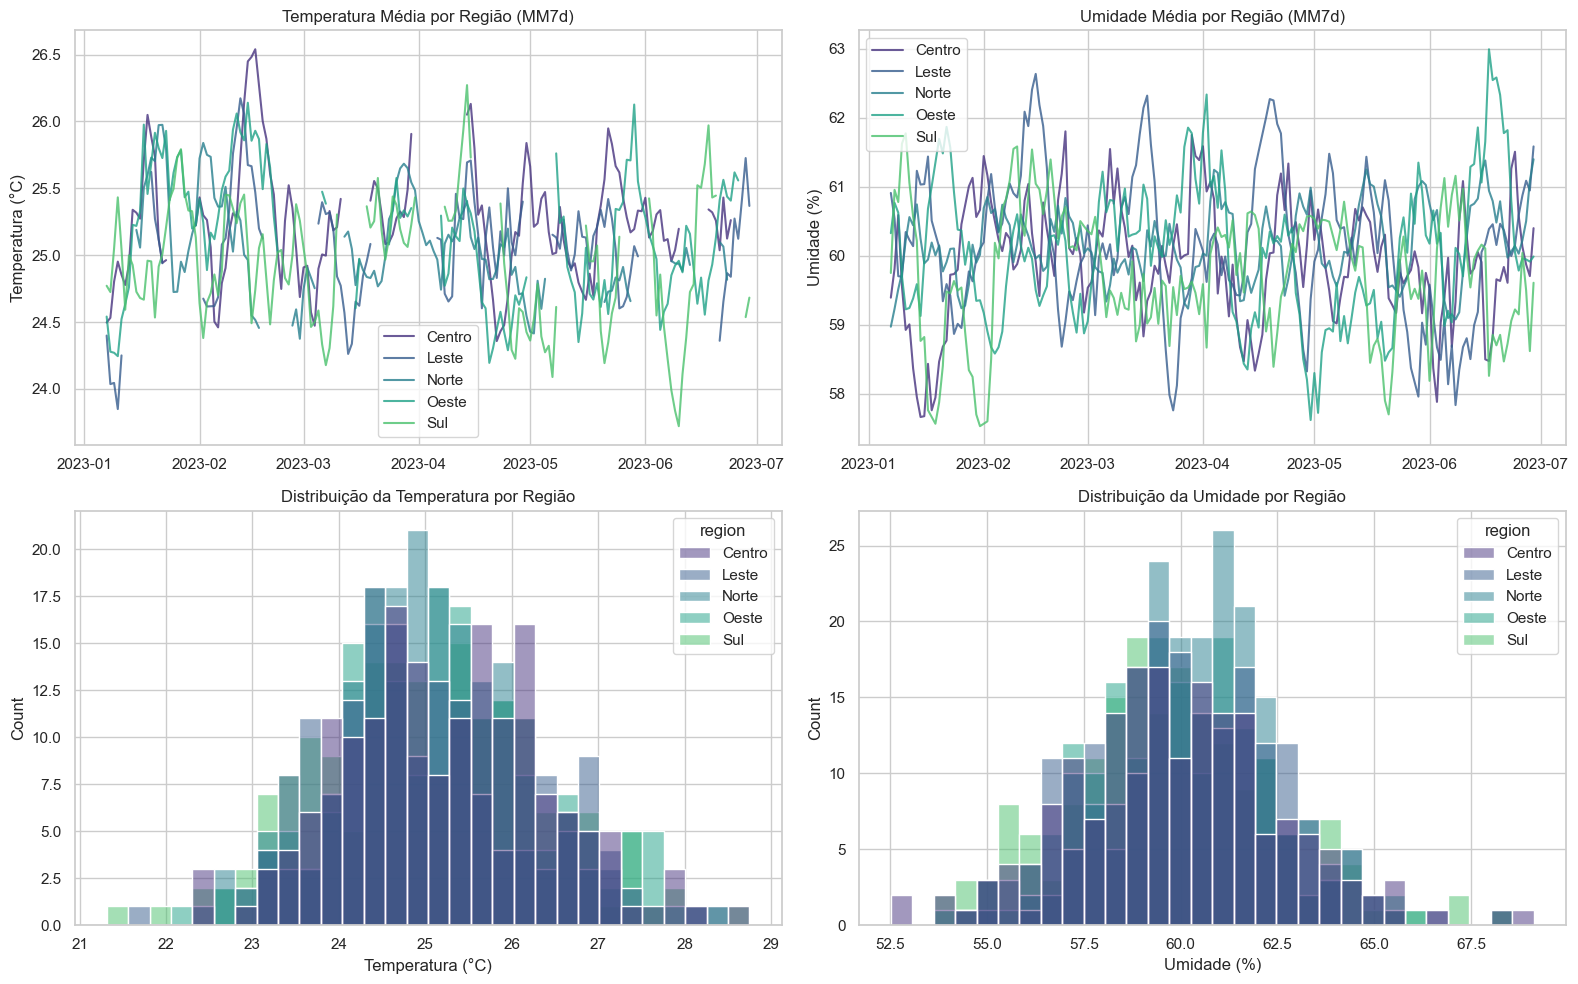

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Temperatura por região ao longo do tempo
for regiao in clima.region.unique():
    d = clima[clima.region == regiao]
    axes[0, 0].plot(d.date, d.temperature.rolling(7).mean(), label=regiao, alpha=0.8)
axes[0, 0].set_title('Temperatura Média por Região (MM7d)')
axes[0, 0].set_ylabel('Temperatura (°C)')
axes[0, 0].legend()

# Umidade por região ao longo do tempo
for regiao in clima.region.unique():
    d = clima[clima.region == regiao]
    axes[0, 1].plot(d.date, d.humidity.rolling(7).mean(), label=regiao, alpha=0.8)
axes[0, 1].set_title('Umidade Média por Região (MM7d)')
axes[0, 1].set_ylabel('Umidade (%)')
axes[0, 1].legend()

# Distribuição de temperatura
sns.histplot(data=clima, x='temperature', hue='region', bins=30, ax=axes[1, 0], alpha=0.5)
axes[1, 0].set_title('Distribuição da Temperatura por Região')
axes[1, 0].set_xlabel('Temperatura (°C)')

# Distribuição de umidade
sns.histplot(data=clima, x='humidity', hue='region', bins=30, ax=axes[1, 1], alpha=0.5)
axes[1, 1].set_title('Distribuição da Umidade por Região')
axes[1, 1].set_xlabel('Umidade (%)')

plt.tight_layout()
plt.savefig('../notebooks/fig_clima.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.9 Correlação entre Consumo e Variáveis Climáticas

In [16]:
# Merge consumo + clientes + clima
df_merged = consumo.merge(clientes, on='client_id', how='left')
df_merged = df_merged.merge(clima, left_on=['region', 'date'], right_on=['region', 'date'], how='left')

print(f'Dataset combinado: {df_merged.shape}')
print(f'Valores nulos após merge:')
print(df_merged.isnull().sum())

# Correlações
corr_cols = ['consumption_kwh', 'temperature', 'humidity']
print(f'\nCorrelações:')
display(df_merged[corr_cols].corr().round(3))

Dataset combinado: (18000, 9)
Valores nulos após merge:
client_id             0
date                  0
consumption_kwh       0
day_of_week           0
month                 0
day_name              0
region                0
temperature        1798
humidity            900
dtype: int64

Correlações:


,consumption_kwh,temperature,humidity
consumption_kwh,1.00,-0.050,-0.000
temperature,-0.05,1.000,0.036
humidity,-0.00,0.036,1.000


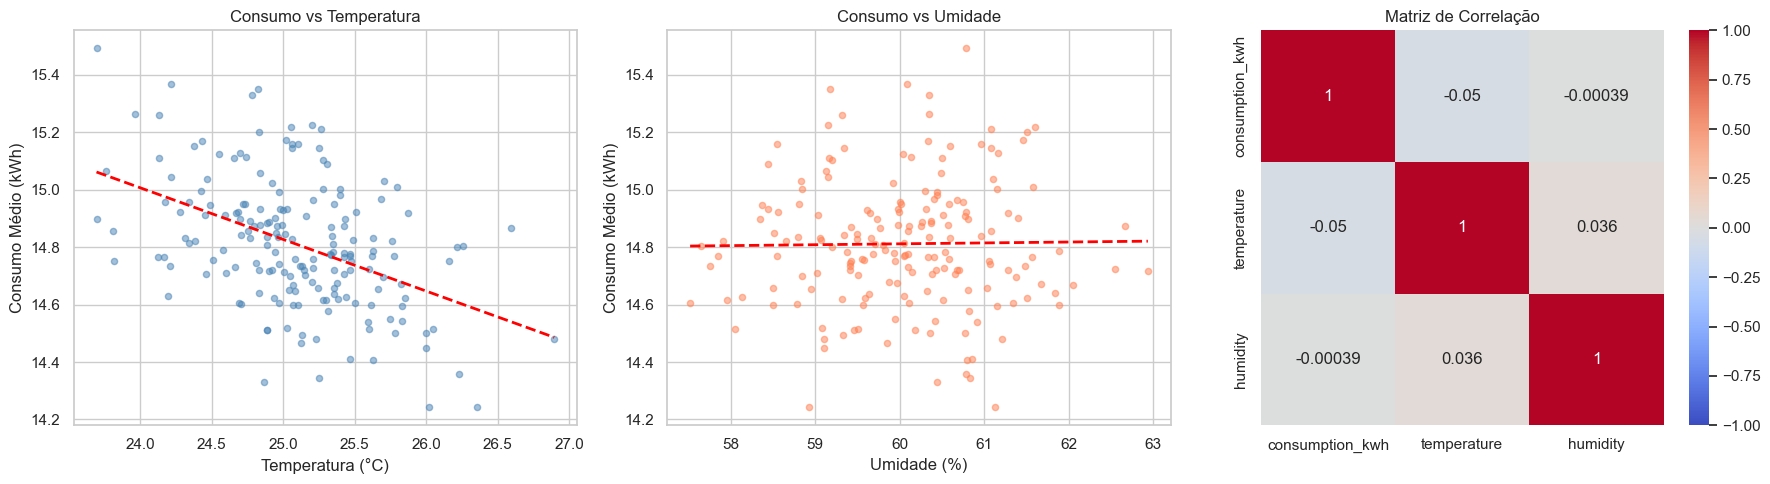

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Consumo vs Temperatura (dados diários agregados)
daily_agg = df_merged.groupby('date').agg(
    consumption_kwh=('consumption_kwh', 'mean'),
    temperature=('temperature', 'mean'),
    humidity=('humidity', 'mean')
).reset_index()

axes[0].scatter(daily_agg.temperature, daily_agg.consumption_kwh, alpha=0.5, s=20, c='steelblue')
z = np.polyfit(daily_agg.temperature.dropna(), daily_agg.consumption_kwh[daily_agg.temperature.notna()], 1)
p = np.poly1d(z)
x_line = np.linspace(daily_agg.temperature.min(), daily_agg.temperature.max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', linewidth=2)
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Consumo Médio (kWh)')
axes[0].set_title('Consumo vs Temperatura')

# Consumo vs Umidade
axes[1].scatter(daily_agg.humidity, daily_agg.consumption_kwh, alpha=0.5, s=20, c='coral')
z2 = np.polyfit(daily_agg.humidity.dropna(), daily_agg.consumption_kwh[daily_agg.humidity.notna()], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(daily_agg.humidity.min(), daily_agg.humidity.max(), 100)
axes[1].plot(x_line2, p2(x_line2), 'r--', linewidth=2)
axes[1].set_xlabel('Umidade (%)')
axes[1].set_ylabel('Consumo Médio (kWh)')
axes[1].set_title('Consumo vs Umidade')

# Heatmap de correlação
corr_matrix = df_merged[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title('Matriz de Correlação')

plt.tight_layout()
plt.savefig('../notebooks/fig_correlacoes.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.10 Análise de Clientes Individuais

In [18]:
# Top 5 e Bottom 5 consumidores
consumo_total_cliente = consumo.groupby('client_id')['consumption_kwh'].agg(['mean', 'std', 'sum']).reset_index()
consumo_total_cliente.columns = ['client_id', 'mean_kwh', 'std_kwh', 'total_kwh']
consumo_total_cliente['cv'] = consumo_total_cliente['std_kwh'] / consumo_total_cliente['mean_kwh']

top5 = consumo_total_cliente.nlargest(5, 'mean_kwh')
bottom5 = consumo_total_cliente.nsmallest(5, 'mean_kwh')

print('Top 5 maiores consumidores (média diária):')
display(top5.round(2))
print('\nTop 5 menores consumidores (média diária):')
display(bottom5.round(2))

Top 5 maiores consumidores (média diária):


,client_id,mean_kwh,std_kwh,total_kwh,cv
30,C0030,19.38,2.23,3487.80,0.12
28,C0028,19.30,2.16,3474.08,0.11
59,C0059,19.21,2.19,3458.67,0.11
96,C0096,19.15,2.30,3447.24,0.12
98,C0098,19.06,2.21,3431.13,0.12



Top 5 menores consumidores (média diária):


,client_id,mean_kwh,std_kwh,total_kwh,cv
29,C0029,9.40,2.26,1691.96,0.24
47,C0047,9.74,2.31,1753.08,0.24
64,C0064,9.91,2.28,1784.33,0.23
89,C0089,10.02,2.10,1803.49,0.21
36,C0036,10.06,2.25,1810.55,0.22


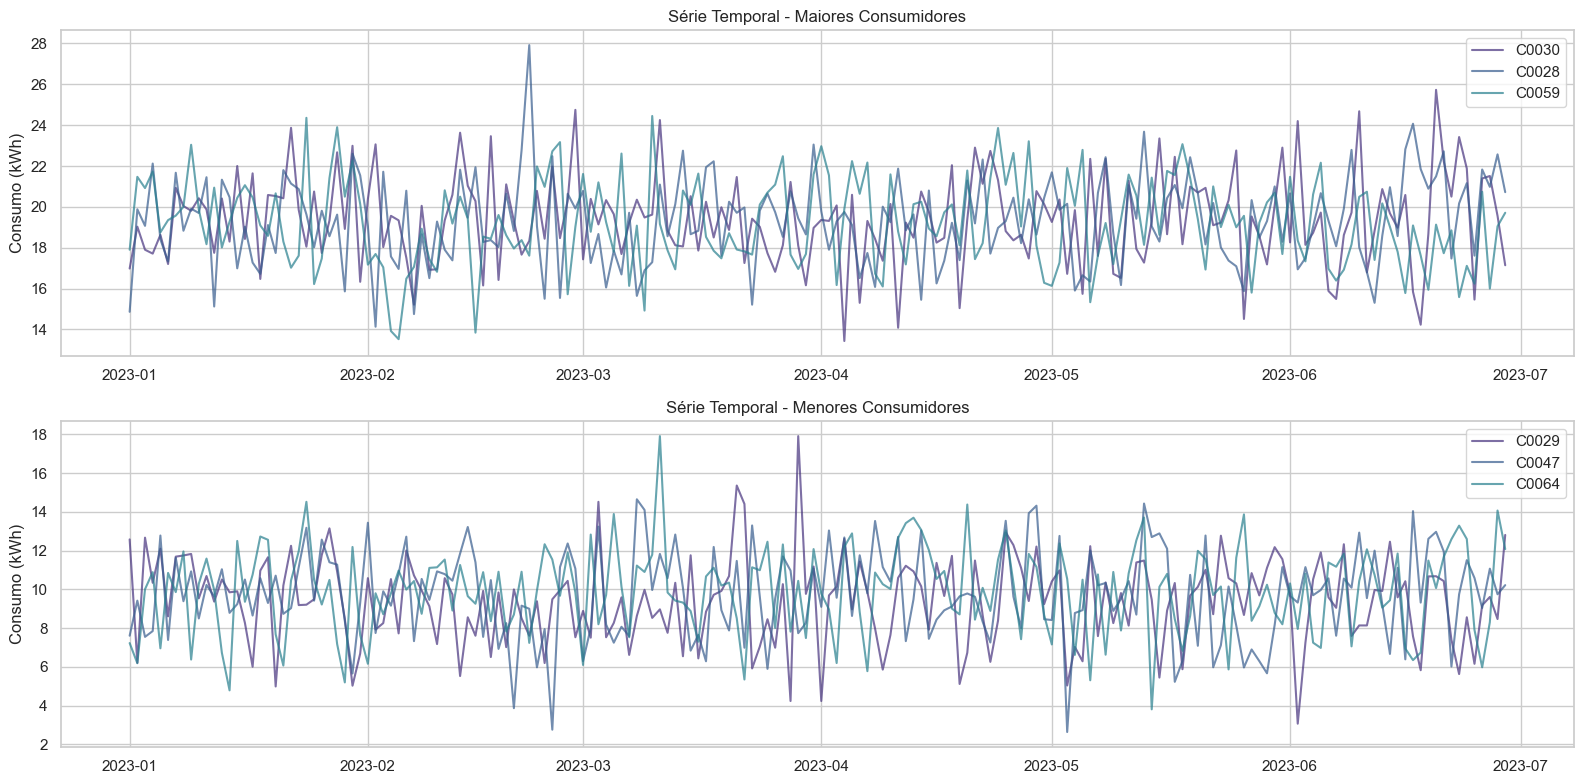

In [19]:
# Visualizar séries de alguns clientes
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for cid in top5.client_id.values[:3]:
    d = consumo[consumo.client_id == cid]
    axes[0].plot(d.date, d.consumption_kwh, label=cid, alpha=0.7)
axes[0].set_title('Série Temporal - Maiores Consumidores')
axes[0].set_ylabel('Consumo (kWh)')
axes[0].legend()

for cid in bottom5.client_id.values[:3]:
    d = consumo[consumo.client_id == cid]
    axes[1].plot(d.date, d.consumption_kwh, label=cid, alpha=0.7)
axes[1].set_title('Série Temporal - Menores Consumidores')
axes[1].set_ylabel('Consumo (kWh)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/fig_clientes_individuais.png', dpi=150, bbox_inches='tight')
plt.show()

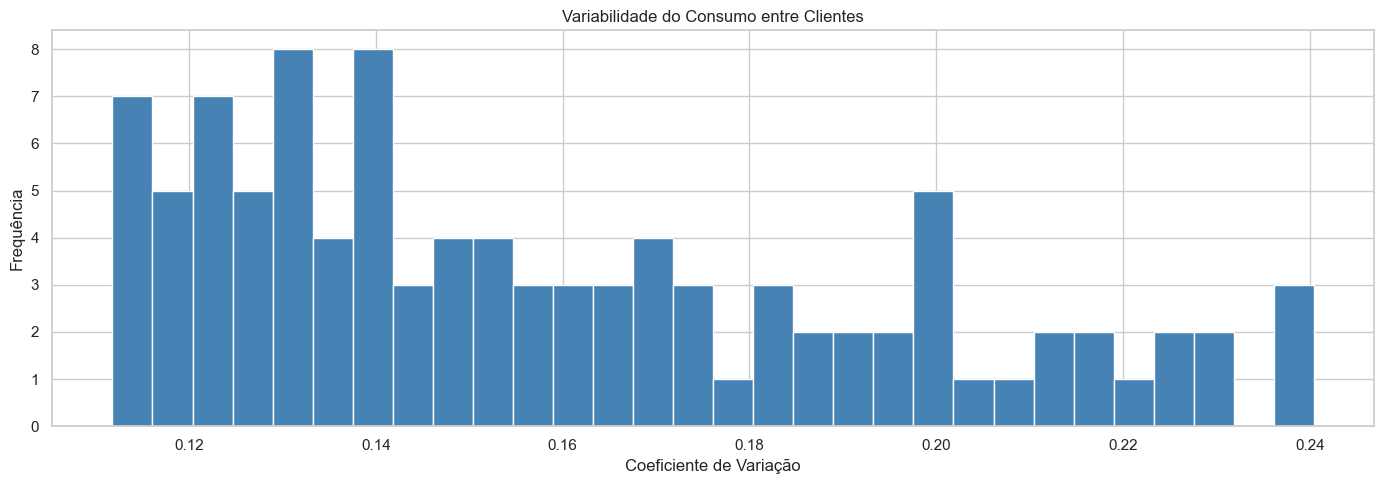

CV médio: 0.159
CV mediano: 0.149


In [20]:
# Distribuição do coeficiente de variação por cliente
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(consumo_total_cliente['cv'], bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Coeficiente de Variação')
ax.set_ylabel('Frequência')
ax.set_title('Variabilidade do Consumo entre Clientes')
plt.tight_layout()
plt.show()

print(f'CV médio: {consumo_total_cliente.cv.mean():.3f}')
print(f'CV mediano: {consumo_total_cliente.cv.median():.3f}')

## 1.11 Resumo da EDA

### Principais Descobertas:

1. **Dados de Consumo**: 18.000 registros para 100 clientes ao longo de 180 dias (Jan-Jun 2023). Sem valores ausentes.

2. **Dados Climáticos**: 900 registros (5 regiões × 180 dias). **45 valores de temperatura ausentes** (~5%) distribuídos entre regiões e meses.

3. **Inconsistências em Clientes**: **5 clientes com região "Desconhecida"** que não correspondem a nenhuma região nos dados climáticos.

4. **Padrões Temporais**: Consumo apresenta tendência sazonal (verão → inverno) e possíveis padrões semanais.

5. **Variáveis Climáticas**: Temperatura e umidade variam entre regiões e ao longo do tempo, com potencial correlação com o consumo.

### Próximos Passos:
- Tratar regiões "Desconhecida" (imputar com base no padrão de consumo ou moda)
- Imputar temperaturas ausentes (interpolação temporal por região)
- Engenharia de features para modelagem preditiva
- Validação temporal com split treino/teste